In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from itertools import product

def gen_env_parameterized(culture="market", num_agents=100, density_param=2):
    '''
    Generates environment explicitly driven by sensitivity analysis parameters.
    '''
    if culture in ["market", "hierarchy"]:
        # density_param maps to m (number of edges to attach from a new node)
        G = nx.barabasi_albert_graph(n=num_agents, m=density_param)
    elif culture in ["adhocracy", "clan"]:
        # density_param maps to k (nearest neighbors)
        G = nx.watts_strogatz_graph(n=num_agents, k=density_param, p=0.1)
    else:
        raise ValueError(f"Invalid culture: {culture}")

    for node in G.nodes():
        G.nodes[node]["is_adopter"] = False
    return G

def define_rogers_agents_parameterized(G, threshold_shift=0.0):
    '''
    Initializes agents with Rogers thresholds plus a global shift (innate resistance).
    '''
    rogers_lookup = {
        0.025: 'Innovator',
        0.160: 'Early Adopter',
        0.500: 'Early Majority',
        0.840: 'Late Majority',
        1.000: 'Laggard'
    }

    threshold_map = {
        'Innovator': (0.0, 0.1),
        'Early Adopter': (0.1, 0.2),
        'Early Majority': (0.2, 0.3),
        'Late Majority': (0.3, 0.7),
        'Laggard': (0.7, 1.0)
    }

    for node in G.nodes():
        definer = np.random.random()
        for upper_bound, category in rogers_lookup.items():
            if definer <= upper_bound:
                rogers = category
                break

        G.nodes[node]['Rogers'] = rogers
        lower_bound, upper_bound = threshold_map[rogers]

        # Calculate baseline threshold
        base_threshold = np.random.uniform(lower_bound, upper_bound)

        # Apply global threshold shift and clamp between 0.0 and 1.0
        shifted_threshold = np.clip(base_threshold + threshold_shift, 0.0, 1.0)
        G.nodes[node]['Threshold'] = round(shifted_threshold, 2)

    return G

def initiate_innovation(G):
    potential_innovators = [n for n in G.nodes() if G.nodes[n]["Rogers"] == "Innovator"]
    if len(potential_innovators) == 0:
        potential_innovators = [n for n in G.nodes() if G.nodes[n]["Rogers"] == "Early Adopter"]

    if len(potential_innovators) == 0:
        innovator = random.choice(list(G.nodes()))
    else:
        innovator = random.choice(potential_innovators)

    G.nodes[innovator]["is_adopter"] = True
    return G, innovator

def simulation_step(G):
    new_adopters = []
    for node in G.nodes():
        if G.nodes[node]["is_adopter"]:
            continue

        neighbors = list(G.neighbors(node))
        if len(neighbors) == 0:
            continue

        adopt_neighbors = sum([1 for n in neighbors if G.nodes[n]['is_adopter']])
        adoption_ratio = adopt_neighbors / len(neighbors)

        if adoption_ratio >= G.nodes[node]["Threshold"]:
            new_adopters.append(node)
    return new_adopters

def run_simulation(G, innovator, max_steps=100):
    current_adopters = {innovator}
    history = [set(current_adopters)]

    for _ in range(max_steps):
        to_add = simulation_step(G)
        if not to_add:
            break
        for node in to_add:
            G.nodes[node]["is_adopter"] = True
            current_adopters.add(node)
        history.append(set(current_adopters))

    return history

In [8]:
# --- EXPERIMENT CONFIGURATION ---
# Axis 1: Company Scales (Number of Agents)
company_sizes = [50, 150, 500, 1000]

# Axis 2: Network Densities (m parameter for Barabasi-Albert)
network_densities = [1, 2, 3, 4]

# Axis 3: Global Threshold Shifts (Tool Resistance Modifier)
threshold_shifts = [-0.15, 0.0, 0.15, 0.30]

# Number of Monte Carlo iterations per specific parameter coordinate
MC_ITERATIONS = 500
results_records = []

print("🚀 Starting Parameter Sweep Experiment...")

# Cartesian product generates all combinations across our 3 axes
parameter_grid = list(product(company_sizes, network_densities, threshold_shifts))
total_combinations = len(parameter_grid)

for idx, (N, m, shift) in enumerate(parameter_grid):
    if (idx + 1) % 10 == 0 or idx == 0:
        print(f"Processing combination {idx + 1}/{total_combinations} | N={N}, m={m}, Shift={shift}")

    runs_saturation = []
    runs_steps = []

    for run in range(MC_ITERATIONS):
        # Build independent network trial instance
        G = gen_env_parameterized(culture="market", num_agents=N, density_param=m)
        G = define_rogers_agents_parameterized(G, threshold_shift=shift)
        G, innovator = initiate_innovation(G)

        history = run_simulation(G, innovator)

        # Calculate resulting metrics
        final_adopters = len(history[-1])
        saturation_rate = final_adopters / N
        steps_taken = len(history)

        runs_saturation.append(saturation_rate)
        runs_steps.append(steps_taken)

    # Aggregate data across the iterations
    results_records.append({
        "Company_Size": N,
        "Network_Density_m": m,
        "Threshold_Shift": shift,
        "Avg_Saturation_Rate": np.mean(runs_saturation),
        "Avg_Steps_To_Equilibrium": np.mean(runs_steps)
    })

# Convert raw records into structured Pandas DataFrame
df_results = pd.DataFrame(results_records)
print("✅ Experiment completed successfully! Data stored in 'df_results'.")
df_results.head()

🚀 Starting Parameter Sweep Experiment...
Processing combination 1/64 | N=50, m=1, Shift=-0.15
Processing combination 10/64 | N=50, m=3, Shift=0.0
Processing combination 20/64 | N=150, m=1, Shift=0.3
Processing combination 30/64 | N=150, m=4, Shift=0.0
Processing combination 40/64 | N=500, m=2, Shift=0.3
Processing combination 50/64 | N=1000, m=1, Shift=0.0
Processing combination 60/64 | N=1000, m=3, Shift=0.3
✅ Experiment completed successfully! Data stored in 'df_results'.


,Company_Size,Network_Density_m,Threshold_Shift,Avg_Saturation_Rate,Avg_Steps_To_Equilibrium
0,50,1,-0.15,0.48068,5.184
1,50,1,0.00,0.05396,1.848
2,50,1,0.15,0.04168,1.538
3,50,1,0.30,0.03448,1.348
4,50,2,-0.15,0.89272,7.908


<>:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Junior\AppData\Local\Temp\ipykernel_29072\1430648356.py:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.xlabel("Threshold Shift ($\Delta T$)", fontsize=10)


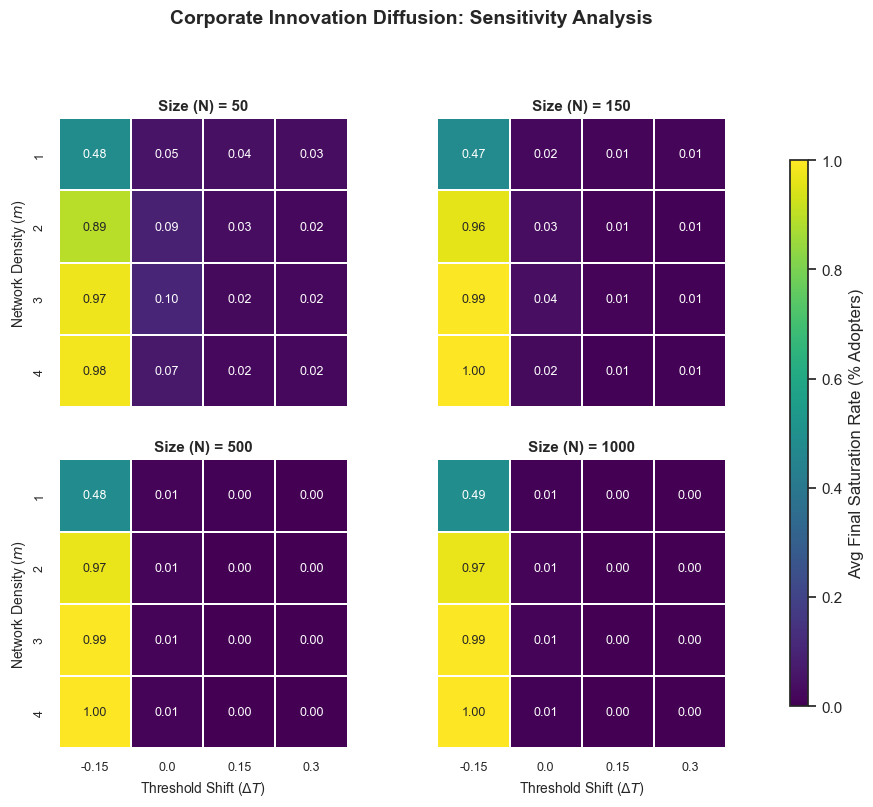

In [9]:
def draw_sensitivity_heatmaps_compact(df):
    '''
    Generates cross-sectional heatmaps with a tight, compact layout
    to easily compare the impact of parameters side-by-side.
    '''
    # Set styling context for clean reporting
    sns.set_theme(style="white", context="notebook")

    def draw_heatmap_facet(*args, **kwargs):
        data = kwargs.pop('data')
        # Pivot the sliced subset to form a 2D grid matrix
        pivot_df = data.pivot(index="Network_Density_m", columns="Threshold_Shift", values="Avg_Saturation_Rate")

        sns.heatmap(
            pivot_df,
            cmap="viridis",
            vmin=0.0, vmax=1.0,
            annot=True, fmt=".2f",
            cbar=False,
            square=True,
            linewidths=.3,
            annot_kws={"size": 9} # Slightly smaller text to fit the tight layout
        )
        plt.xlabel("Threshold Shift ($\Delta T$)", fontsize=10)
        plt.ylabel("Network Density ($m$)", fontsize=10)
        plt.tick_params(labelsize=9)

    # Initialize FacetGrid separating charts by Company Size
    # Lowering height/aspect slightly keeps the multi-plot grid tight
    g = sns.FacetGrid(df, col="Company_Size", col_wrap=2, height=4.2, aspect=1.1)
    g.map_dataframe(draw_heatmap_facet)

    g.set_titles(template="Size (N) = {col_name}", size=11, weight='bold')

    # CRITICAL CHANGES: hspace and wspace significantly reduced to pull plots closer
    plt.subplots_adjust(top=0.85, bottom=0.1, left=0.08, right=0.88, hspace=0.18, wspace=0.05)

    # Place the main colorbar compactly on the right side
    cbar_ax = g.fig.add_axes([0.91, 0.15, 0.02, 0.65])
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=1))
    g.fig.colorbar(sm, cax=cbar_ax, label="Avg Final Saturation Rate (% Adopters)")

    g.fig.suptitle("Corporate Innovation Diffusion: Sensitivity Analysis", fontsize=14, weight='bold')

    plt.show()

# Execute the updated visualization
draw_sensitivity_heatmaps_compact(df_results)

🔄 Running 500 Monte Carlo simulations to calculate the true average...


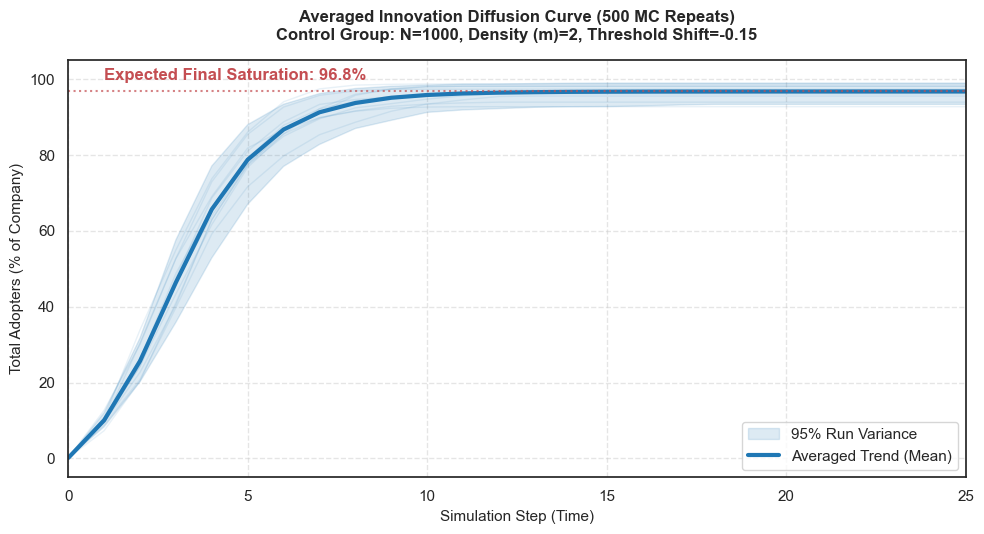

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SETUP CONTROL GROUP PARAMETERS ---
N_control = 1000
m_control = 2
shift_control = -0.15
MC_REPEATS = 500
MAX_STEPS = 50  # Cap the steps so the matrix columns align perfectly

# Matrix to store the adoption percentage at each step for all 500 runs
# Shape: (500 runs, 50 steps)
adoption_matrix = np.zeros((MC_REPEATS, MAX_STEPS))

print(f"🔄 Running {MC_REPEATS} Monte Carlo simulations to calculate the true average...")

# --- 2. EXECUTE THE MONTE CARLO LOOP ---
for run in range(MC_REPEATS):
    # Generate independent network instance
    G_control = gen_env_parameterized(culture="market", num_agents=N_control, density_param=m_control)
    G_control = define_rogers_agents_parameterized(G_control, threshold_shift=shift_control)
    G_control, innovator = initiate_innovation(G_control)

    # Run simulation
    history_control = run_simulation(G_control, innovator, max_steps=MAX_STEPS)

    # Pad the simulation with its final state if it terminates early
    final_counts = [len(adopters) for adopters in history_control]
    while len(final_counts) < MAX_STEPS:
        final_counts.append(final_counts[-1])

    # Convert to percentages and store in our matrix
    pct_counts = [(count / N_control) * 100 for count in final_counts]
    adoption_matrix[run, :] = pct_counts

# --- 3. CALCULATE MEAN AND CONFIDENCE INTERVALS ---
mean_curve = np.mean(adoption_matrix, axis=0)
std_curve = np.std(adoption_matrix, axis=0)
# 95% Confidence Interval bounds
ci_lower = np.percentile(adoption_matrix, 2.5, axis=0)
ci_upper = np.percentile(adoption_matrix, 97.5, axis=0)

# --- 4. PLOT THE AGGREGATE RESULTS ---
plt.figure(figsize=(10, 5.5))

# Plot the 95% Confidence Interval background to show run variance
plt.fill_between(range(MAX_STEPS), ci_lower, ci_upper, color='#1f77b4', alpha=0.15, label='95% Run Variance')

# Plot individual sample lines (first 10 runs) faintly to visually demonstrate background chaos
for i in range(10):
    plt.plot(range(MAX_STEPS), adoption_matrix[i, :], color='#1f77b4', alpha=0.1, linewidth=1)

# Plot the clean, averaged trend line
plt.plot(range(MAX_STEPS), mean_curve, color='#1f77b4', linewidth=3, label='Averaged Trend (Mean)')

# Styling, Labels, and Metadata
plt.title(f"Averaged Innovation Diffusion Curve ({MC_REPEATS} MC Repeats)\nControl Group: N={N_control}, Density (m)={m_control}, Threshold Shift={shift_control}",
          fontsize=12, weight='bold', pad=15)
plt.xlabel("Simulation Step (Time)", fontsize=11)
plt.ylabel("Total Adopters (% of Company)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-5, 105)
plt.xlim(0, 25) # Zoom in on where the action happens before stabilizing
plt.legend(loc='lower right', frameon=True)

# Annotate final averaged saturation value
plt.axhline(y=mean_curve[-1], color='r', linestyle=':', alpha=0.7)
plt.text(1, mean_curve[-1] + 3, f"Expected Final Saturation: {mean_curve[-1]:.1f}%", color='r', weight='bold')

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

# --- EXPERIMENT CONFIGURATION ---
N_fixed = 500              # As requested
m_fixed = 2                # Using m=2 to allow structural loops
MC_ITERATIONS = 20         # Repeats per unique threshold
max_steps = 100

# Generate threshold shifts from -0.30 to 0.30 in steps of 0.01
# Using round to avoid floating-point precision issues in Python
threshold_shifts = [round(t, 2) for t in np.arange(-0.30, 0.31, 0.01)]

detailed_records = []

print(f"🔄 Starting granular sweep: {len(threshold_shifts)} distinct thresholds × {MC_ITERATIONS} runs...")

# --- EXECUTE THE SWEEP ---
for shift in threshold_shifts:
    for run in range(MC_ITERATIONS):
        # 1. Generate the network environment
        G = gen_env_parameterized(culture="market", num_agents=N_fixed, density_param=m_fixed)
        G = define_rogers_agents_parameterized(G, threshold_shift=shift)
        G, innovator = initiate_innovation(G)

        # 2. Run simulation
        history = run_simulation(G, innovator, max_steps=max_steps)

        # 3. Calculate metrics for this specific universe
        final_adopters = len(history[-1])
        adoption_rate = (final_adopters / N_fixed) * 100
        steps_to_equilibrium = len(history)

        # Record every single data point individually (no averaging yet!)
        detailed_records.append({
            "Threshold_Shift": shift,
            "Iteration": run,
            "Adoption_Rate": adoption_rate,
            "Steps_Taken": steps_to_equilibrium
        })

# Store in a detailed DataFrame
df_scatter = pd.DataFrame(detailed_records)
print(f"✅ Sweep complete! Recorded {len(df_scatter)} individual simulation outcomes.")

🔄 Starting granular sweep: 61 distinct thresholds × 20 runs...
✅ Sweep complete! Recorded 1220 individual simulation outcomes.


<>:35: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:35: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Junior\AppData\Local\Temp\ipykernel_29072\182202635.py:35: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.xlabel("Global Threshold Shift ($\Delta T$)", fontsize=11)


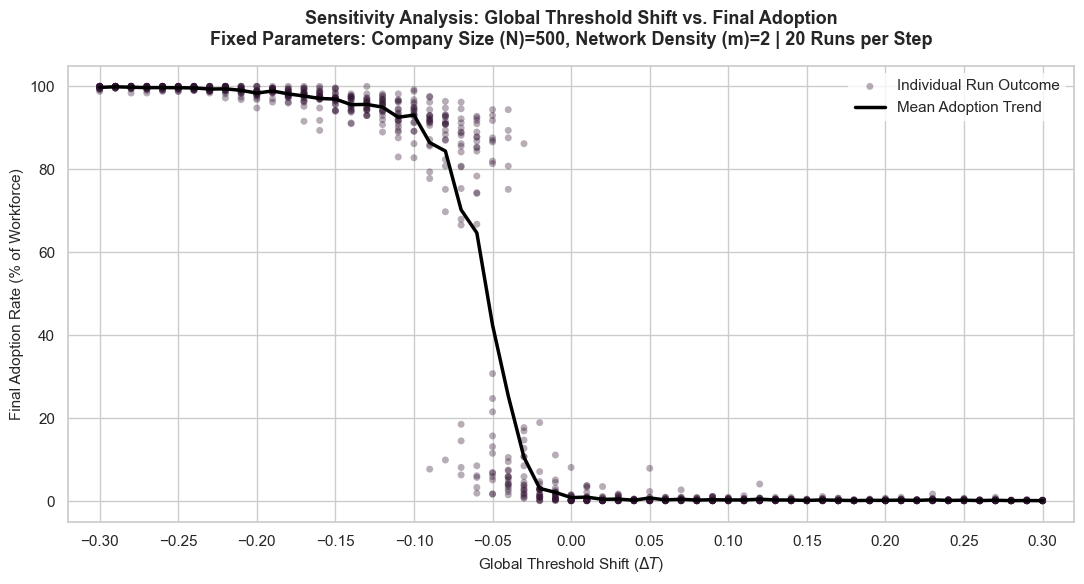

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean trendline to overlay on the raw scatter data
df_means = df_scatter.groupby("Threshold_Shift")["Adoption_Rate"].mean().reset_index()

# Setup professional plotting aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(11, 6))

# 1. Plot the raw scatter points (all 1,220 runs)
plt.scatter(
    df_scatter["Threshold_Shift"],
    df_scatter["Adoption_Rate"],
    alpha=0.35,
    color='#311432',    # Deep purple/dark tone for contrast
    edgecolors='none',
    s=25,
    label='Individual Run Outcome'
)

# 2. Overlay a crisp trend line linking the means of each step
plt.plot(
    df_means["Threshold_Shift"],
    df_means["Adoption_Rate"],
    color='black',    # Bright blue for the macro trend
    linewidth=2.5,
    linestyle='-',
    label='Mean Adoption Trend'
)

# Chart Details & Typography
plt.title(f"Sensitivity Analysis: Global Threshold Shift vs. Final Adoption\nFixed Parameters: Company Size (N)={N_fixed}, Network Density (m)={m_fixed} | 20 Runs per Step",
          fontsize=13, weight='bold', pad=15)
plt.xlabel("Global Threshold Shift ($\Delta T$)", fontsize=11)
plt.ylabel("Final Adoption Rate (% of Workforce)", fontsize=11)

plt.xlim(-0.32, 0.32)
plt.ylim(-5, 105)
plt.xticks(np.arange(-0.30, 0.35, 0.05))
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np

# --- EXPERIMENT CONFIGURATION ---
N_fixed = 500              # Keep company size consistent
shift_fixed = 0.1          # High friction barrier for the experiment
MC_ITERATIONS = 20         # 20 independent universes per density step
max_steps = 100

# Sweep network density (m) from 1 to 30 sequentially
density_values = list(range(1, 31))

density_records = []

print(f"🔄 Starting density sweep: {len(density_values)} distinct densities × {MC_ITERATIONS} runs...")

# --- EXECUTE THE SWEEP ---
for m in density_values:
    for run in range(MC_ITERATIONS):
        # 1. Generate the network environment with changing density
        G = gen_env_parameterized(culture="market", num_agents=N_fixed, density_param=m)
        G = define_rogers_agents_parameterized(G, threshold_shift=shift_fixed)
        G, innovator = initiate_innovation(G)

        # 2. Run simulation
        history = run_simulation(G, innovator, max_steps=max_steps)

        # 3. Calculate metrics for this specific layout
        final_adopters = len(history[-1])
        adoption_rate = (final_adopters / N_fixed) * 100
        steps_to_equilibrium = len(history)

        # Record raw data point
        density_records.append({
            "Network_Density_m": m,
            "Iteration": run,
            "Adoption_Rate": adoption_rate,
            "Steps_Taken": steps_to_equilibrium
        })

# Store in a structured DataFrame
df_density_scatter = pd.DataFrame(density_records)
print(f"✅ Sweep complete! Recorded {len(df_density_scatter)} individual simulation outcomes.")

🔄 Starting density sweep: 30 distinct densities × 20 runs...
✅ Sweep complete! Recorded 600 individual simulation outcomes.


In [20]:
import pandas as pd
import numpy as np

# --- EXPERIMENT CONFIGURATION ---
N_fixed = 500              # Keep company size consistent
shift_fixed = -0.1          # High friction barrier for the experiment
MC_ITERATIONS = 20         # 20 independent universes per density step
max_steps = 100

# Sweep network density (m) from 1 to 30 sequentially
density_values = list(range(1, 31))

density_records = []

print(f"🔄 Starting density sweep: {len(density_values)} distinct densities × {MC_ITERATIONS} runs...")

# --- EXECUTE THE SWEEP ---
for m in density_values:
    for run in range(MC_ITERATIONS):
        # 1. Generate the network environment with changing density
        G = gen_env_parameterized(culture="market", num_agents=N_fixed, density_param=m)
        G = define_rogers_agents_parameterized(G, threshold_shift=shift_fixed)
        G, innovator = initiate_innovation(G)

        # 2. Run simulation
        history = run_simulation(G, innovator, max_steps=max_steps)

        # 3. Calculate metrics for this specific layout
        final_adopters = len(history[-1])
        adoption_rate = (final_adopters / N_fixed) * 100
        steps_to_equilibrium = len(history)

        # Record raw data point
        density_records.append({
            "Network_Density_m": m,
            "Iteration": run,
            "Adoption_Rate": adoption_rate,
            "Steps_Taken": steps_to_equilibrium
        })

# Store in a structured DataFrame
df_density_scatter = pd.DataFrame(density_records)
print(f"✅ Sweep complete! Recorded {len(df_density_scatter)} individual simulation outcomes.")

🔄 Starting density sweep: 30 distinct densities × 20 runs...
✅ Sweep complete! Recorded 600 individual simulation outcomes.


<>:34: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:34: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Junior\AppData\Local\Temp\ipykernel_29072\1845927031.py:34: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.title(f"Sensitivity Analysis: Network Density ($m$) vs. Final Adoption\nFixed Parameters: Company Size (N)={N_fixed}, Threshold Shift ($\Delta T$)={shift_fixed} | 20 Runs per Step",


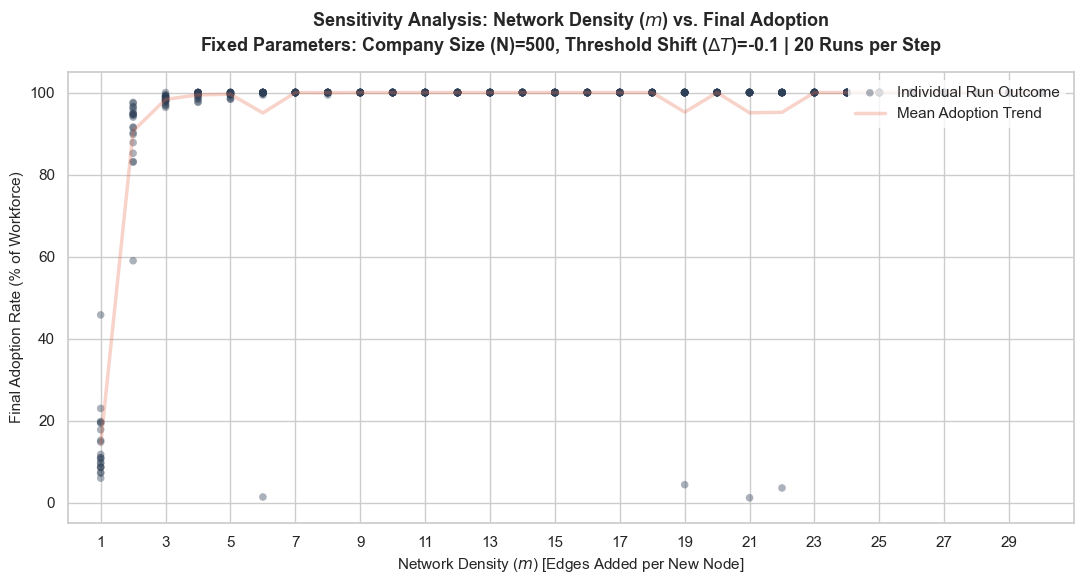

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean trendline for the density settings
df_density_means = df_density_scatter.groupby("Network_Density_m")["Adoption_Rate"].mean().reset_index()

# Setup professional plotting aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(11, 6))

# 1. Plot the raw scatter points (600 total simulation runs)
plt.scatter(
    df_density_scatter["Network_Density_m"],
    df_density_scatter["Adoption_Rate"],
    alpha=0.4,
    color='#2E4057',    # Sleek dark slate blue
    edgecolors='none',
    s=30,
    label='Individual Run Outcome'
)

# 2. Overlay the mean trend line
plt.plot(
    df_density_means["Network_Density_m"],
    df_density_means["Adoption_Rate"],
    color='#E76F51',    # Terracotta orange for contrasting trend
    linewidth=2.5,
    linestyle='-',
    alpha = 0.3,
    label='Mean Adoption Trend'
)

# Chart Details & Typography
plt.title(f"Sensitivity Analysis: Network Density ($m$) vs. Final Adoption\nFixed Parameters: Company Size (N)={N_fixed}, Threshold Shift ($\Delta T$)={shift_fixed} | 20 Runs per Step",
          fontsize=13, weight='bold', pad=15)
plt.xlabel("Network Density ($m$) [Edges Added per New Node]", fontsize=11)
plt.ylabel("Final Adoption Rate (% of Workforce)", fontsize=11)

plt.xlim(0, 31)
plt.ylim(-5, 105)
plt.xticks(np.arange(1, 31, 2))
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()